# Анализ журнала сделок

Ноутбук только читает `data/trade_journal.csv` и не обращается к Bitunix. Запускайте ячейки сверху вниз.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-darkgrid")

## 1. Загрузка CSV

Путь определяется автоматически при запуске Jupyter из корня проекта или папки `notebooks`.

In [2]:
cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "pyproject.toml").exists() else cwd.parent
journal_path = repo_root / "data" / "trade_journal.csv"

if not journal_path.exists():
    raise FileNotFoundError(f"Журнал пока не найден: {journal_path}")

journal_path

PosixPath('/home/liudmila/futures_bot/data/trade_journal.csv')

In [3]:
expected_columns = [
    "event_type", "status", "symbol", "side", "order_type",
    "entry_price", "quantity", "leverage", "stop_loss",
    "take_profit", "client_id", "order_id", "position_id",
    "pnl", "fee", "funding", "net_pnl", "remaining_quantity",
    "source_event_id", "event_id", "timestamp",
]
numeric_columns = [
    "entry_price", "quantity", "leverage", "stop_loss",
    "take_profit", "pnl", "fee", "funding", "net_pnl",
    "remaining_quantity",
]

journal = pd.read_csv(journal_path, dtype=str, keep_default_na=False)
for column in expected_columns:
    if column not in journal.columns:
        journal[column] = ""
for column in numeric_columns:
    journal[column] = pd.to_numeric(journal[column], errors="coerce")
journal["timestamp"] = pd.to_datetime(
    journal["timestamp"], errors="coerce", utc=True
)
journal = journal.sort_values("timestamp", na_position="last").reset_index(drop=True)

print(f"Файл: {journal_path}")
print(f"Строк: {len(journal):,}")
print(f"Период: {journal['timestamp'].min()} — {journal['timestamp'].max()}")
display(journal.tail(10))

Файл: /home/liudmila/futures_bot/data/trade_journal.csv
Строк: 1,598
Период: 2026-07-27 10:55:10.314294+00:00 — 2026-08-06 05:34:39.218312+00:00


,event_type,status,symbol,side,order_type,entry_price,quantity,leverage,risk_percent,stop_loss,take_profit,proposal_id,execution_id,user_id,mode,client_id,order_id,position_id,simulated,error,pnl,source_event_id,event_id,timestamp,fee,funding,net_pnl,remaining_quantity
1588,tp_order,TP2_ACTIVE,,,,NaN,NaN,NaN,,NaN,NaN,,,,,bot-13cbcddb23964fb59098-2,2156482066215830812,4523286791237396726,,,NaN,tp-order:2156482066215830812,dfb4727fe7144723882a13f46ef8999d,2026-08-05 09:38:03.639580+00:00,NaN,NaN,NaN,NaN
1589,planned_tp_status,CONFIGURED,,,,NaN,NaN,NaN,,NaN,NaN,,,,,bot-13cbcddb23964fb59098-2,,,,,NaN,plan:bot-13cbcddb23964fb59098-2:CONFIGURED,af55bed3e53f427bb1b2fa5a7f9d7b81,2026-08-05 09:38:03.640247+00:00,NaN,NaN,NaN,NaN
1590,tp_order,TP3_ACTIVE,,,,NaN,NaN,NaN,,NaN,NaN,,,,,bot-13cbcddb23964fb59098-3,3057875923615609485,3413514649458479036,,,NaN,tp-order:3057875923615609485,eadca7db72624ddf86bb58d69c799ca2,2026-08-05 09:38:06.291923+00:00,NaN,NaN,NaN,NaN
1591,planned_tp_status,CONFIGURED,,,,NaN,NaN,NaN,,NaN,NaN,,,,,bot-13cbcddb23964fb59098-3,,,,,NaN,plan:bot-13cbcddb23964fb59098-3:CONFIGURED,dd2025cbe5c94de2a1511c9f30f816d4,2026-08-05 09:38:06.484773+00:00,NaN,NaN,NaN,NaN
1592,reconciliation,COMPLETED,,,,NaN,3.0,NaN,,NaN,NaN,,,,,,0,,,,NaN,,aeb30c2931c34924b6ae5ab25f58c7fc,2026-08-05 09:39:26.009609+00:00,NaN,NaN,NaN,NaN
1593,reconciliation,COMPLETED,,,,NaN,3.0,NaN,,NaN,NaN,,,,,,0,,,,NaN,,451d3a5ad9354759a19da775ef009013,2026-08-05 09:54:48.816151+00:00,NaN,NaN,NaN,NaN
1594,reconciliation,COMPLETED,,,,NaN,3.0,NaN,,NaN,NaN,,,,,,0,,,,NaN,,e4a80ff9c9f5486a8441353c0819ac42,2026-08-05 11:10:22.883791+00:00,NaN,NaN,NaN,NaN
1595,reconciliation,COMPLETED,,,,NaN,3.0,NaN,,NaN,NaN,,,,,,0,,,,NaN,,fd5b1ea44ada42058f00656ce7ad53d5,2026-08-05 11:12:31.326274+00:00,NaN,NaN,NaN,NaN
1596,reconciliation,COMPLETED,,,,NaN,3.0,NaN,,NaN,NaN,,,,,,0,,,,NaN,,1906b97952354343afffa55bc7b02fe6,2026-08-05 11:12:44.804485+00:00,NaN,NaN,NaN,NaN
1597,reconciliation,COMPLETED,,,,NaN,3.0,NaN,,NaN,NaN,,,,,,0,,,,NaN,,d478c87451e94f298a18e13fa9254094,2026-08-06 05:34:39.218312+00:00,NaN,NaN,NaN,NaN


## 2. Основные показатели

Расчёты строятся по `TRADE_SUMMARY`, поэтому закрытая позиция учитывается один раз.

In [4]:
trades = journal.loc[journal["event_type"].eq("TRADE_SUMMARY")].copy()
trades = trades.drop_duplicates("source_event_id", keep="last")

closed_count = len(trades)
wins = int(trades["net_pnl"].gt(0).sum())
losses = int(trades["net_pnl"].lt(0).sum())
breakeven = int(trades["net_pnl"].eq(0).sum())
win_rate = wins / closed_count * 100 if closed_count else 0

metrics = pd.Series({
    "Закрытых сделок": closed_count,
    "Прибыльных": wins,
    "Убыточных": losses,
    "Без результата": breakeven,
    "Win rate, %": round(win_rate, 2),
    "Realized PnL": trades["pnl"].sum(min_count=1),
    "Комиссии": trades["fee"].abs().sum(min_count=1),
    "Funding": trades["funding"].sum(min_count=1),
    "Чистый PnL": trades["net_pnl"].sum(min_count=1),
    "Средний PnL": trades["net_pnl"].mean(),
    "Лучший результат": trades["net_pnl"].max(),
    "Худший результат": trades["net_pnl"].min(),
})
display(metrics.to_frame("Значение"))

,Значение
Закрытых сделок,59.000000
Прибыльных,34.000000
Убыточных,25.000000
Без результата,0.000000
"Win rate, %",57.630000
Realized PnL,-7.802751
Комиссии,2.720134
Funding,0.120797
Чистый PnL,-10.402088
Средний PnL,-0.176307


## 3. Последние завершённые сделки

In [5]:
trade_columns = [
    "timestamp", "symbol", "side", "quantity", "entry_price",
    "pnl", "fee", "funding", "net_pnl", "position_id",
]
display(trades[trade_columns].sort_values("timestamp", ascending=False).head(20))

,timestamp,symbol,side,quantity,entry_price,pnl,fee,funding,net_pnl,position_id
1539,2026-08-04 11:22:42.644589+00:00,LINKUSDT,SHORT,0.0,NaN,0.021788,-0.030829,0.009657,0.000616,5751198414269316058
1532,2026-08-04 11:22:42.439140+00:00,LINKUSDT,SHORT,0.0,NaN,0.036354,-0.051438,0.016112,0.001028,386649443592173850
1522,2026-08-04 11:22:42.035234+00:00,1000BONKUSDT,SHORT,0.0,NaN,0.103939,-0.024870,0.005077,0.084147,3795740882257685087
1519,2026-08-04 11:22:41.849989+00:00,1000BONKUSDT,SHORT,0.0,NaN,0.155897,-0.037302,0.007616,0.126210,7811018820669705638
1509,2026-08-04 11:22:41.022846+00:00,1000BONKUSDT,SHORT,0.0,NaN,0.259837,-0.062173,0.012693,0.210357,4553744124249809610
1500,2026-08-04 11:22:27.245599+00:00,LINKUSDT,SHORT,0.0,NaN,0.021689,-0.020549,0.006438,0.007578,4356510375222168574
1454,2026-08-03 17:31:08.653116+00:00,BCHUSDT,SHORT,0.0,NaN,-3.463169,-0.173970,0.011031,-3.626108,602860011321869985
1438,2026-08-03 15:01:53.886104+00:00,AVAXUSDT,SHORT,0.0,NaN,-1.120221,-0.058221,0.000000,-1.178442,8735079254457151518
1429,2026-08-03 15:01:48.658140+00:00,AVAXUSDT,SHORT,0.0,NaN,-0.617343,-0.032343,0.000000,-0.649685,5478267364386991161
1421,2026-08-03 15:01:41.380311+00:00,AVAXUSDT,SHORT,0.0,NaN,-0.505880,-0.025880,0.000000,-0.531760,989241827980753605


## 4. Накопительный чистый PnL

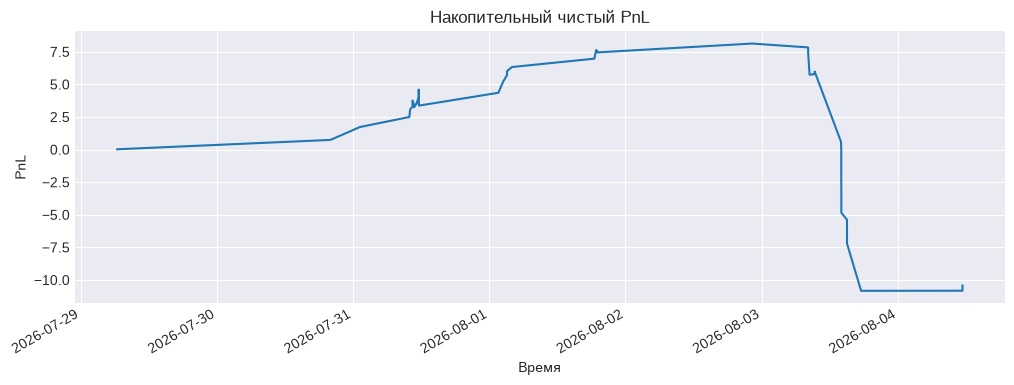

In [6]:
equity = trades.dropna(subset=["timestamp", "net_pnl"]).sort_values("timestamp").copy()
equity["cumulative_net_pnl"] = equity["net_pnl"].cumsum()

if equity.empty:
    print("Пока нет завершённых сделок с рассчитанным net_pnl.")
else:
    ax = equity.plot(
        x="timestamp", y="cumulative_net_pnl", figsize=(12, 4),
        title="Накопительный чистый PnL", legend=False,
    )
    ax.set_xlabel("Время")
    ax.set_ylabel("PnL")
    plt.show()

## 5. Результаты по торговым парам

In [7]:
if trades.empty:
    print("Пока нет завершённых сделок.")
else:
    by_symbol = trades.groupby("symbol", dropna=False).agg(
        trades=("position_id", "count"),
        wins=("net_pnl", lambda values: values.gt(0).sum()),
        net_pnl=("net_pnl", "sum"),
        average_pnl=("net_pnl", "mean"),
        fees=("fee", lambda values: values.abs().sum()),
        funding=("funding", "sum"),
    )
    by_symbol["win_rate_pct"] = by_symbol["wins"] / by_symbol["trades"] * 100
    display(by_symbol.sort_values("net_pnl", ascending=False))

,trades,wins,net_pnl,average_pnl,fees,funding,win_rate_pct
symbol,,,,,,,
MYXUSDT,5,5,2.959617,0.591923,0.050216,-0.029341,100.000000
OPUSDT,10,6,1.977204,0.197720,0.234601,0.014018,60.000000
SAHARAUSDT,5,5,1.364242,0.272848,0.317646,0.000000,100.000000
ENAUSDT,5,2,1.123828,0.224766,0.146085,0.026529,40.000000
1000BONKUSDT,3,3,0.420714,0.140238,0.124345,0.025386,100.000000
WLFIUSDT,3,3,0.238373,0.079458,0.207003,0.000000,100.000000
NEARUSDT,3,1,0.189989,0.063330,0.085100,-0.005405,33.333333
ETHUSDT,5,5,0.024197,0.004839,0.342321,0.000000,100.000000
LINKUSDT,3,3,0.009222,0.003074,0.102816,0.032207,100.000000


## 6. Результаты по дням

In [8]:
daily_source = trades.dropna(subset=["timestamp"]).copy()
daily_source["day"] = daily_source["timestamp"].dt.tz_convert("Europe/Moscow").dt.date
daily = daily_source.groupby("day").agg(
    trades=("position_id", "count"),
    net_pnl=("net_pnl", "sum"),
    fees=("fee", lambda values: values.abs().sum()),
    funding=("funding", "sum"),
)
display(daily.sort_index(ascending=False).head(30))

,trades,net_pnl,fees,funding
day,,,,
2026-08-04,6,0.429936,0.227161,0.057593
2026-08-03,20,-18.288332,1.221419,0.011783
2026-08-01,10,4.083445,0.196301,-0.002812
2026-07-31,17,2.630742,0.689239,0.054578
2026-07-30,1,0.717923,0.043693,-0.000345
2026-07-29,5,0.024197,0.342321,0.000000


## 7. Исполнения ENTRY, TP и SL

In [9]:
execution_mask = journal["event_type"].eq("ENTRY") | journal["event_type"].eq("SL") | journal["event_type"].str.fullmatch(r"TP[1-5]", na=False)
executions = journal.loc[execution_mask, [
    "timestamp", "event_type", "symbol", "side", "entry_price",
    "take_profit", "stop_loss", "quantity", "remaining_quantity",
    "pnl", "fee", "funding", "order_id", "position_id",
]]
display(executions.sort_values("timestamp", ascending=False).head(50))

,timestamp,event_type,symbol,side,entry_price,take_profit,stop_loss,quantity,remaining_quantity,pnl,fee,funding,order_id,position_id
1554,2026-08-04 11:26:10.167867+00:00,ENTRY,AAVEUSDT,Sell,91.830000,91.020000,NaN,1.200,NaN,NaN,0.055098,NaN,2084601782973894656,
1360,2026-08-03 13:58:44.952235+00:00,SL,SUIUSDT,Buy,NaN,NaN,0.69590,411.600,NaN,NaN,NaN,NaN,2357994388468181095,8970739525931887432
1238,2026-08-03 09:00:59.870663+00:00,ENTRY,SUIUSDT,Sell,0.684800,0.680000,NaN,411.600,NaN,NaN,0.140932,NaN,2084202861592174592,
1204,2026-08-03 08:46:58.465825+00:00,ENTRY,AVAXUSDT,Sell,6.410000,6.303000,NaN,9.000,NaN,NaN,0.028845,NaN,2084199332437680128,
1124,2026-08-03 08:12:40.755314+00:00,ENTRY,DOGEUSDT,Sell,0.069200,0.068150,NaN,1113.000,NaN,NaN,0.019255,NaN,2084190701906444288,
1041,2026-08-03 07:57:23.851707+00:00,ENTRY,1000BONKUSDT,Sell,0.002821,0.002790,NaN,22094.000,NaN,NaN,0.031164,NaN,2084186856102940672,
1011,2026-08-02 22:20:28.729939+00:00,TP1,OPUSDT,Sell,NaN,0.087800,NaN,475.000,NaN,NaN,NaN,NaN,6960137183462273563,6591199400387405508
899,2026-08-01 18:59:50.716000+00:00,SL,ENAUSDT,Buy,NaN,NaN,0.08035,183.000,NaN,NaN,NaN,NaN,999998268957295684,3312784281954565619
898,2026-08-01 18:59:48.726139+00:00,SL,ENAUSDT,Buy,NaN,NaN,0.08035,274.000,NaN,NaN,NaN,NaN,7715407734135922854,2993456890121190151
887,2026-08-01 18:50:05.898930+00:00,TP2,ENAUSDT,Buy,NaN,0.078860,NaN,456.000,NaN,NaN,NaN,NaN,1873718617865909931,6572015807412744187


## 8. Проверка качества данных

Показывает пропущенные ID, дубли событий и незаполненные итоговые показатели.

In [10]:
quality = pd.Series({
    "Дубли source_event_id": journal.loc[journal["source_event_id"].ne(""), "source_event_id"].duplicated().sum(),
    "TP/SL без order_id": executions.loc[executions["event_type"].ne("ENTRY"), "order_id"].eq("").sum(),
    "Итоги без position_id": trades["position_id"].eq("").sum(),
    "Итоги без net_pnl": trades["net_pnl"].isna().sum(),
    "Некорректные timestamp": journal["timestamp"].isna().sum(),
})
display(quality.to_frame("Количество"))

,Количество
Дубли source_event_id,0
TP/SL без order_id,0
Итоги без position_id,0
Итоги без net_pnl,0
Некорректные timestamp,0


## 9. Экспорт завершённых сделок

Раскомментируйте строку записи, если нужен отдельный компактный CSV.

In [ ]:
export_path = repo_root / "data" / "trade_summary_export.csv"
# trades[trade_columns].to_csv(export_path, index=False)
export_path